# Self-Organizing Maps
___
## Text Dataset

In [22]:
#Library Import
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics.pairwise import euclidean_distances
import random
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

#### Text Pre-Process

In [2]:
import nltk
from nltk.corpus import words, stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download('words')
nltk.download('stopwords')
nltk.download('wordnet')

# Set of English words from nltk
ENGLISH_WORDS = set(words.words())

def is_english_word(word):
    return word.lower() in ENGLISH_WORDS

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

def preprocess_paragraph(paragraph):
    # Tokenize the paragraph into words
    words = paragraph.split()
    # Lemmatize each word and filter out stopwords and non-English words
    lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in words]
    filtered_words = [word for word in lemmatized_words if word not in STOP_WORDS and is_english_word(word)]
    # Get unique words
    unique_words = set(filtered_words)
    return unique_words

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### Load Text

In [3]:
pickle_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop1\Pickle\Uncanny"
pickle_files = [os.path.join(pickle_folder, file) for file in os.listdir(pickle_folder) if file.endswith('.pkl')]

text_data = []
for file in pickle_files:
    with open(file, 'rb') as f:
        data = pickle.load(f)
        
        text_data.extend(data)

In [4]:
# Collect all 'TEXT' values from pickle files
all_texts = []
for root, dirs, files in os.walk(pickle_folder):
    for file_name in files:
        if file_name.endswith(".pkl"):
            file_path = os.path.join(root, file_name)
            if os.path.getsize(file_path) > 0:  # Ensure the file is not empty
                print(f"Processing file: {file_name} in folder: {root}")
                try:
                    with open(file_path, "rb") as f:
                        data = pickle.load(f)

                        # Handle different data structures
                        if isinstance(data, list):  # If it's a list
                            print(f"Data type: List with {len(data)} items.")
                            for item in data:
                                if isinstance(item, dict) and "TEXT" in item:
                                    all_texts.append(item["TEXT"])
                        elif isinstance(data, dict):  # If it's a dictionary
                            print(f"Data type: Dictionary with keys: {list(data.keys())}")
                            if "TEXT" in data:
                                all_texts.append(data["TEXT"])
                        else:
                            print("Unhandled data type.")
                except Exception as e:
                    print(f"Error loading {file_name}: {e}")

print(f"Total texts collected: {len(all_texts)}")

Processing file: Aesthetic Anxiety_ Uncanny Symp - Laurie Ruth Johnson_processed.pkl in folder: E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop1\Pickle\Uncanny
Data type: List with 2322 items.
Processing file: Are Numbers Real__ The Uncanny Relationshi - Brian Clegg_processed.pkl in folder: E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop1\Pickle\Uncanny
Data type: List with 1604 items.
Processing file: Bhopal's Ecological Gothic_ Dis - Pramod K. Nayar_processed.pkl in folder: E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop1\Pickle\Uncanny
Data type: List with 1634 items.
Processing file: Chronotopes of the Uncanny_ Time and Space - Petra Eckhard_processed.pkl in folder: E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop1\Pickle\Uncanny
Data type: List with 1587 items.
Processing file: Daimonic Imagination_ Uncanny I - Angela Voss_processed.pkl in folder: 

In [5]:
first_10 = all_texts[:10]
for i, paragraph in enumerate(first_10):
    print(f"Paragraph {i+1}:\n{paragraph}\n")

Paragraph 1:
Aesthetic Anxiety141Internationale Forschungen zurAllgemeinen undVergleichenden LiteraturwissenschaftIn Verbindung mitNorbert Bachleitner (Universität Wien), Dietrich Briesemeister (Friedrich Schiller-Universität Jena), Francis Claudon (Université Paris XII), Joachim Knape (Universität Tübingen), Klaus Ley (Johannes Gutenberg-Universität Mainz), John A. McCarthy (Vanderbilt University), Alfred Noe (Universität Wien), Manfred Pfister (Freie Universität Berlin), Sven H. Rossel (Universität Wien)

Paragraph 2:
herausgegeben vonAlberto Martino(Universität Wien)Redaktion: Paul Ferstl und Rudolf PölzerAnschrift der Redaktion: Institut für Vergleichende Literaturwissenschaft, Berggasse 11/5, A-1090 WienLaurie Ruth Johnson

Paragraph 3:
Amsterdam - New York, NY 2010Aesthetic AnxietyUncanny Symptoms in GermanLiterature and CultureCover photo: Scott LiddellCover design: Pier PostLe papier sur lequel le présent ouvrage est imprimé remplit les prescriptions de “ISO 9706:1994, Informat

In [6]:
all_unique_words = set()
for paragraph in all_texts:
    unique_words = preprocess_paragraph(paragraph)
    all_unique_words.update(unique_words) 

In [7]:
all_processed_words = list(all_unique_words)

In [8]:
# Optionally, print out a preview of the processed words from the first paragraph
print(all_processed_words[:1000]) 

['relation', 'pen', 'batten', 'solicit', 'communality', 'outlined', 'beer', 'crystallize', 'vicarage', 'dualistically', 'keystone', 'releasement', 'decrease', 'printing', 'legenda', 'pensioner', 'shop', 'unbind', 'sickle', 'transmitter', 'pound', 'lustrate', 'prate', 'chatting', 'nowise', 'yesternight', 'piling', 'grub', 'sweetheart', 'slouch', 'pray', 'consolidated', 'magniloquent', 'naked', 'inherent', 'rowed', 'maund', 'offish', 'dignitary', 'strangles', 'turf', 'stirless', 'successively', 'hysteric', 'incredibility', 'cultivate', 'propertied', 'tantara', 'shy', 'intracardiac', 'transmutation', 'maternality', 'corporeally', 'glia', 'detectable', 'forage', 'diverge', 'lumber', 'unequal', 'powdery', 'slaved', 'eyrie', 'virile', 'outward', 'plumy', 'magnum', 'irksome', 'trust', 'filthy', 'comfortless', 'suitably', 'amoroso', 'transmuting', 'web', 'mark', 'trail', 'undistinguishable', 'congenital', 'cataract', 'superintendent', 'puppet', 'underside', 'elide', 'unsupervised', 'compacted'

In [9]:
print(len(all_processed_words))

31665


#### Vectorize Words with TF-IDF

In [10]:
vectorizer = TfidfVectorizer(max_features=1000)
total_words = len(all_processed_words)
vectorizer.fit(all_processed_words)
X_dense = []

for idx, doc in enumerate(all_processed_words):
    X_doc = vectorizer.transform([doc])  
    X_dense.append(X_doc.toarray())  

    if idx % 100 == 0 or idx == total_words - 1:
        print(f"Processed {idx + 1}/{total_words} ({(idx + 1) / total_words * 100:.2f}%)")

X_dense = np.vstack(X_dense)
print("Finished vectorizing the text data using TF-IDF.")

Processed 1/31665 (0.00%)
Processed 101/31665 (0.32%)
Processed 201/31665 (0.63%)
Processed 301/31665 (0.95%)
Processed 401/31665 (1.27%)
Processed 501/31665 (1.58%)
Processed 601/31665 (1.90%)
Processed 701/31665 (2.21%)
Processed 801/31665 (2.53%)
Processed 901/31665 (2.85%)
Processed 1001/31665 (3.16%)
Processed 1101/31665 (3.48%)
Processed 1201/31665 (3.79%)
Processed 1301/31665 (4.11%)
Processed 1401/31665 (4.42%)
Processed 1501/31665 (4.74%)
Processed 1601/31665 (5.06%)
Processed 1701/31665 (5.37%)
Processed 1801/31665 (5.69%)
Processed 1901/31665 (6.00%)
Processed 2001/31665 (6.32%)
Processed 2101/31665 (6.64%)
Processed 2201/31665 (6.95%)
Processed 2301/31665 (7.27%)
Processed 2401/31665 (7.58%)
Processed 2501/31665 (7.90%)
Processed 2601/31665 (8.21%)
Processed 2701/31665 (8.53%)
Processed 2801/31665 (8.85%)
Processed 2901/31665 (9.16%)
Processed 3001/31665 (9.48%)
Processed 3101/31665 (9.79%)
Processed 3201/31665 (10.11%)
Processed 3301/31665 (10.42%)
Processed 3401/31665 (10

In [11]:
print(len(X_dense))

31665


In [12]:
pickle_folder = "Pickle"
os.makedirs(pickle_folder, exist_ok=True)

with open(os.path.join(pickle_folder, "Text_Vector.pkl"), "wb") as vector_file:
    pickle.dump(X_dense, vector_file)

with open(os.path.join(pickle_folder, "Text_Data.pkl"), "wb") as data_file:
    pickle.dump(all_processed_words, data_file)

print("Data saved to pickle files in 'Pickle' folder: 'Text_Vector.pkl' and 'Text_Data.pkl'")

Data saved to pickle files in 'Pickle' folder: 'Text_Vector.pkl' and 'Text_Data.pkl'


#### Code

In [13]:
# Define the SOM grid initialization
def initialize_SOM(n_rows, n_cols, n_features):
    SOM = np.random.rand(n_rows, n_cols, n_features)
    return SOM

# Define the BMU finding function
def find_BMU(SOM, x):
    distSq = (np.square(SOM - x)).sum(axis=2)
    return np.unravel_index(np.argmin(distSq, axis=None), distSq.shape)

# Define the weight update function
def update_weights(SOM, train_ex, learn_rate, radius_sq, BMU_coord, step=3):
    g, h = BMU_coord
    if radius_sq < 1e-3:
        SOM[g,h,:] += learn_rate * (train_ex - SOM[g,h,:])
        return SOM
    for i in range(max(0, g-step), min(SOM.shape[0], g+step)):
        for j in range(max(0, h-step), min(SOM.shape[1], h+step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / 2 / radius_sq)
            SOM[i,j,:] += learn_rate * dist_func * (train_ex - SOM[i,j,:])   
    return SOM    

# Training the SOM with progress bar
def train_SOM_with_progress(SOM, train_data, learn_rate=0.1, radius_sq=1, 
                            lr_decay=0.1, radius_decay=0.1, epochs=10):    
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    
    for epoch in tqdm(range(epochs), desc="Training SOM", unit="epoch"):
        np.random.shuffle(train_data)  # Shuffle the training data
        
        for train_ex in train_data:
            g, h = find_BMU(SOM, train_ex)
            SOM = update_weights(SOM, train_ex, learn_rate, radius_sq, (g,h))
        
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)
    
    return SOM

In [17]:
def visualize_SOM_words(SOM, text_data, grid_height=15, grid_width=15):
    num_words = len(text_data)

    total_cells = grid_height * grid_width
    if num_words > total_cells:
        words_to_display = text_data[:total_cells]  
    else:
        words_to_display = text_data 
    
    fig, ax = plt.subplots(grid_height, grid_width, figsize=(15, 15))
    
    word_idx = 0 
    
    for i in range(grid_height):
        for j in range(grid_width):
            ax[i, j].axis('off') 
            
            if word_idx < len(words_to_display):
                ax[i, j].text(0.5, 0.5, words_to_display[word_idx], ha='center', va='center', fontsize=8)
                word_idx += 1 
    
    plt.tight_layout()
    plt.show()

In [19]:
def visualize_SOM(SOM, text_data):
    som_height = 15  # Set the SOM height
    som_width = 15   # Set the SOM width
    
    fig, ax = plt.subplots(som_height, som_width, figsize=(15, 15))
    
    for i in range(som_height):
        for j in range(som_width):
            ax[i, j].axis('off')
            bmu_idx = find_BMU(SOM, SOM[i, j, :])  # Find the BMU for each SOM cell
            ax[i, j].text(0.5, 0.5, text_data[bmu_idx[0]], ha='center', va='center', fontsize=8)  # Display the text in the grid
    
    plt.tight_layout()
    plt.show()

In [41]:
def plot_SOM_activation(SOM, data, word_vectors, som_height, som_width):
    # Create a grid to hold activation values
    activations = np.zeros((som_height, som_width))

    # Calculate activation values for each SOM cell
    for i in range(som_height):
        for j in range(som_width):
            bmu_idx = find_BMU(SOM, SOM[i, j, :])  # Find the Best Matching Unit (BMU)
            activations[i, j] = np.linalg.norm(SOM[i, j, :] - word_vectors[bmu_idx[0]])  # Activation: distance from BMU

    # Normalize the activations to range between 0 and 1 for coloring
    scaler = MinMaxScaler(feature_range=(0, 1))
    activations_normalized = scaler.fit_transform(activations.reshape(-1, 1)).reshape(som_height, som_width)

    # Plot the activations with the Blue color map
    plt.figure(figsize=(15, 15))
    plt.imshow(activations_normalized, cmap='Blues', interpolation='nearest')
    plt.colorbar(label='Activation Strength')

    # Add words as labels in the grid cells
    for i in range(som_height):
        for j in range(som_width):
            bmu_idx = find_BMU(SOM, SOM[i, j, :])  # Find BMU for this grid cell
            ax = plt.gca()
            ax.text(j, i, data[bmu_idx[0]], ha='center', va='center', fontsize=8, color='white', fontweight='bold')

    plt.title("SOM Activation Map")
    plt.axis('off')
    plt.show()


In [47]:
def find_BMU(SOM, word_vector):
    # This is a placeholder function. You should replace it with the actual BMU finding logic.
    distances = np.linalg.norm(SOM - word_vector, axis=-1)
    return np.unravel_index(np.argmin(distances), distances.shape)

def visualize_SOM_uniquewords(SOM, all_processed_words, X_dense, som_height, som_width):
    # Create a grid to hold activation values
    activations = np.zeros((som_height, som_width))

    # Create a dictionary to store which words are displayed in each SOM cell
    word_grid = {}

    # Calculate the BMU for each word and assign it to the grid
    word_idx = 0
    for idx, word in enumerate(all_processed_words):
        word_vector = X_dense[idx]  # Get the vector for the word from X_dense
        bmu_idx = find_BMU(SOM, word_vector)  # Find the BMU for each word
        i, j = bmu_idx  # BMU grid coordinates

        # Ensure each cell gets only one word
        if (i, j) not in word_grid:
            word_grid[(i, j)] = word
            activations[i, j] += np.linalg.norm(SOM[i, j, :] - word_vector)  # Activation: distance from BMU

            # If we have filled all the cells, stop assigning more words
            word_idx += 1
            if word_idx >= len(all_processed_words):
                break

    # Normalize activations to the range [0, 1] for coloring
    scaler = MinMaxScaler(feature_range=(0, 1))
    activations_normalized = scaler.fit_transform(activations.reshape(-1, 1)).reshape(som_height, som_width)

    # Plot the activations with the Blue color map as the background (with 50% opacity)
    plt.figure(figsize=(15, 15))
    plt.imshow(activations_normalized, cmap='Blues', interpolation='nearest', alpha=0.5)

    # Add words as labels in the grid cells
    for i in range(som_height):
        for j in range(som_width):
            if (i, j) in word_grid:
                plt.text(j, i, word_grid[(i, j)], ha='center', va='center', fontsize=8, color='black', fontweight='bold')

    plt.title("SOM Activation Map with Words")
    plt.axis('off')
    plt.colorbar(label='Activation Strength')
    plt.tight_layout()
    plt.show()

#### Execute

In [14]:
print(X_dense.shape)

(31665, 1000)


In [15]:
# Initialize the SOM grid with a 15x15 size
SOM = initialize_SOM(15, 15, X_dense.shape[1])
epochs = 50 
SOM = train_SOM_with_progress(SOM, X_dense, epochs=epochs, learn_rate=0.1, radius_sq=1, lr_decay=0.05, radius_decay=0.05)

print("SOM training complete.")

Training SOM: 100%|█████████████████████████████████████████████████████████████████| 50/50 [23:17<00:00, 27.95s/epoch]

SOM training complete.


C:\Users\Patrick\AppData\Local\Temp\ipykernel_34724\3500143424.py:13: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


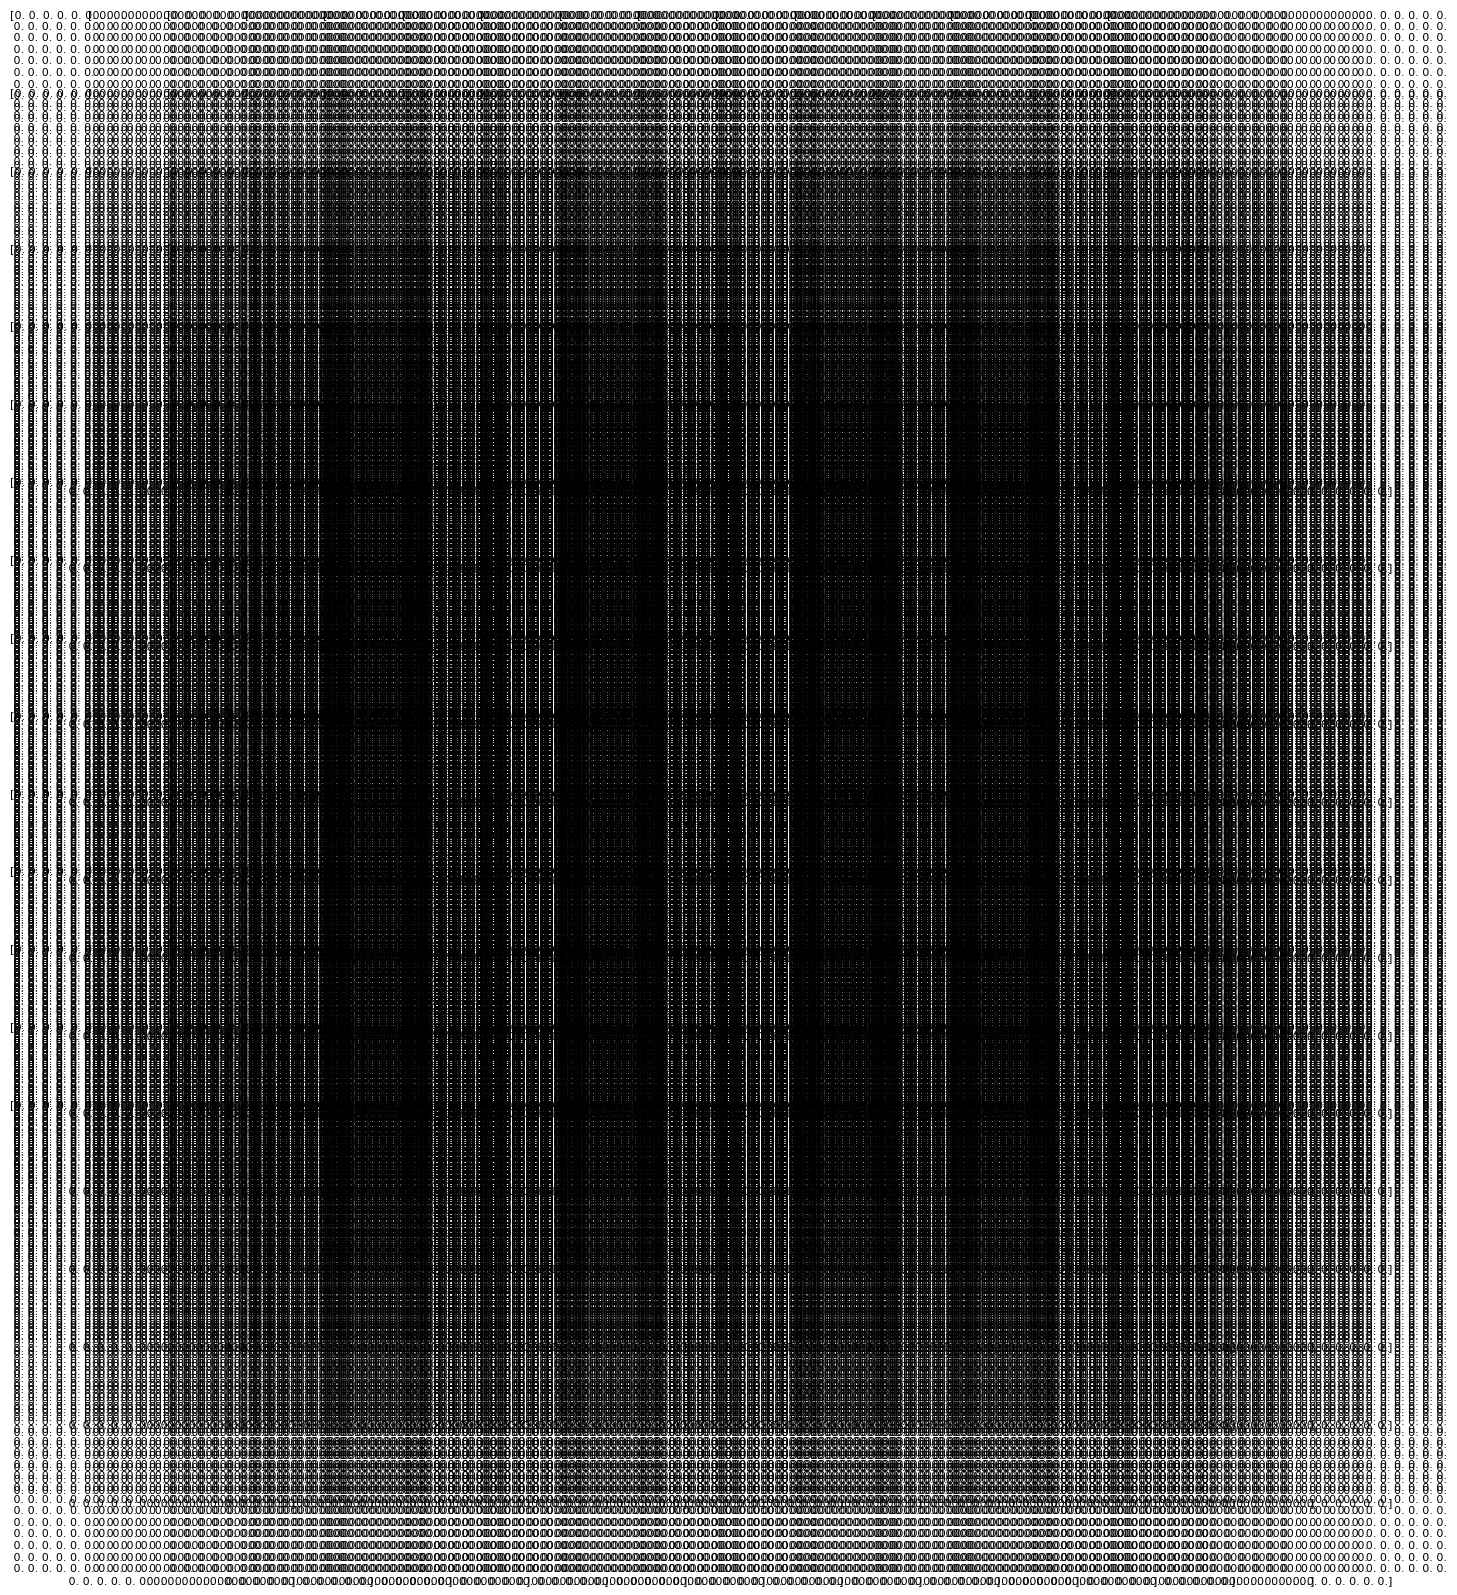

In [21]:
visualize_SOM(SOM, X_dense)

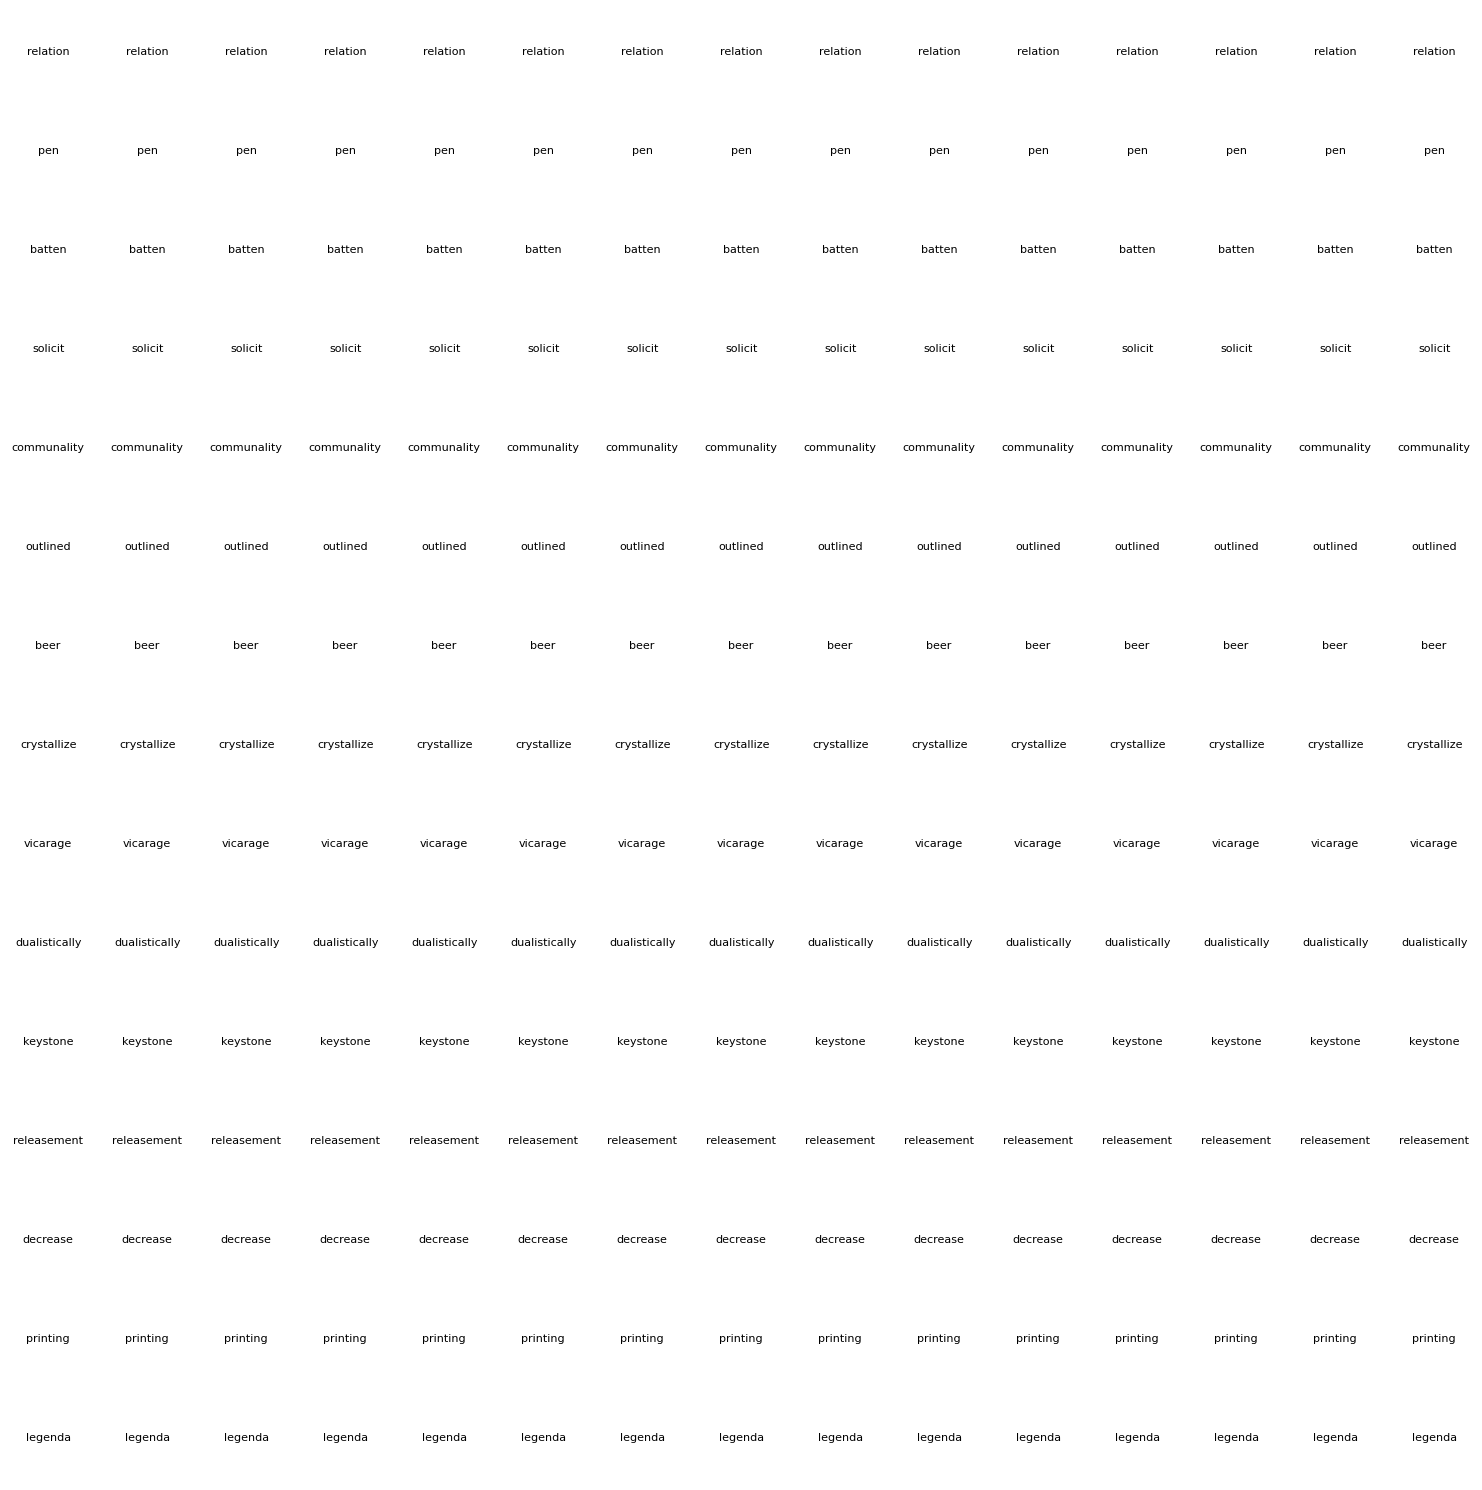

In [20]:
visualize_SOM(SOM, all_processed_words)

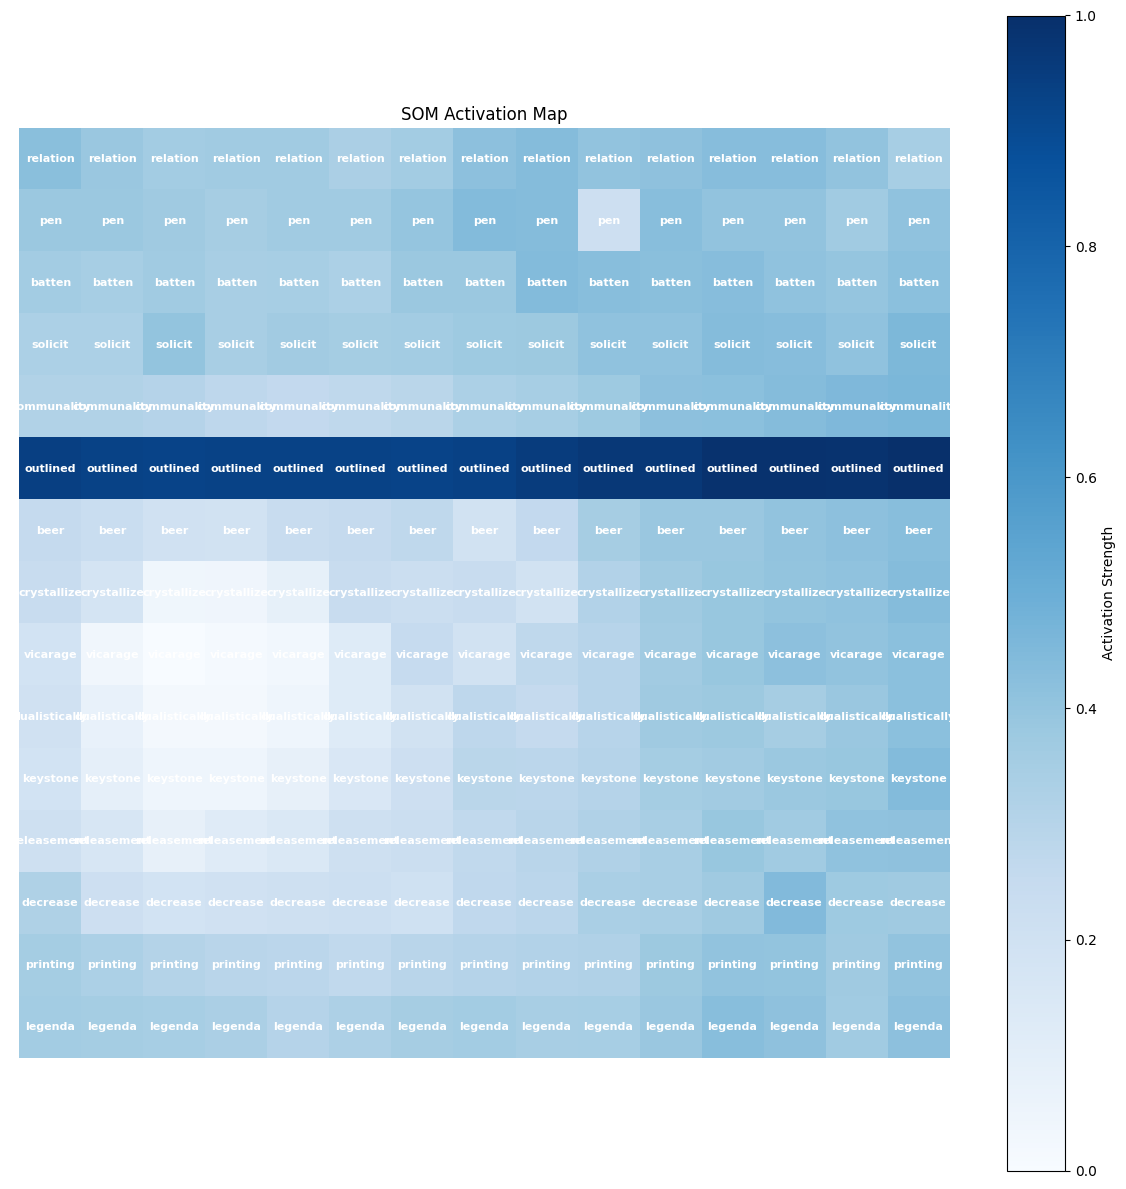

In [42]:
plot_SOM_activation(SOM, all_processed_words, X_dense, 15, 15)

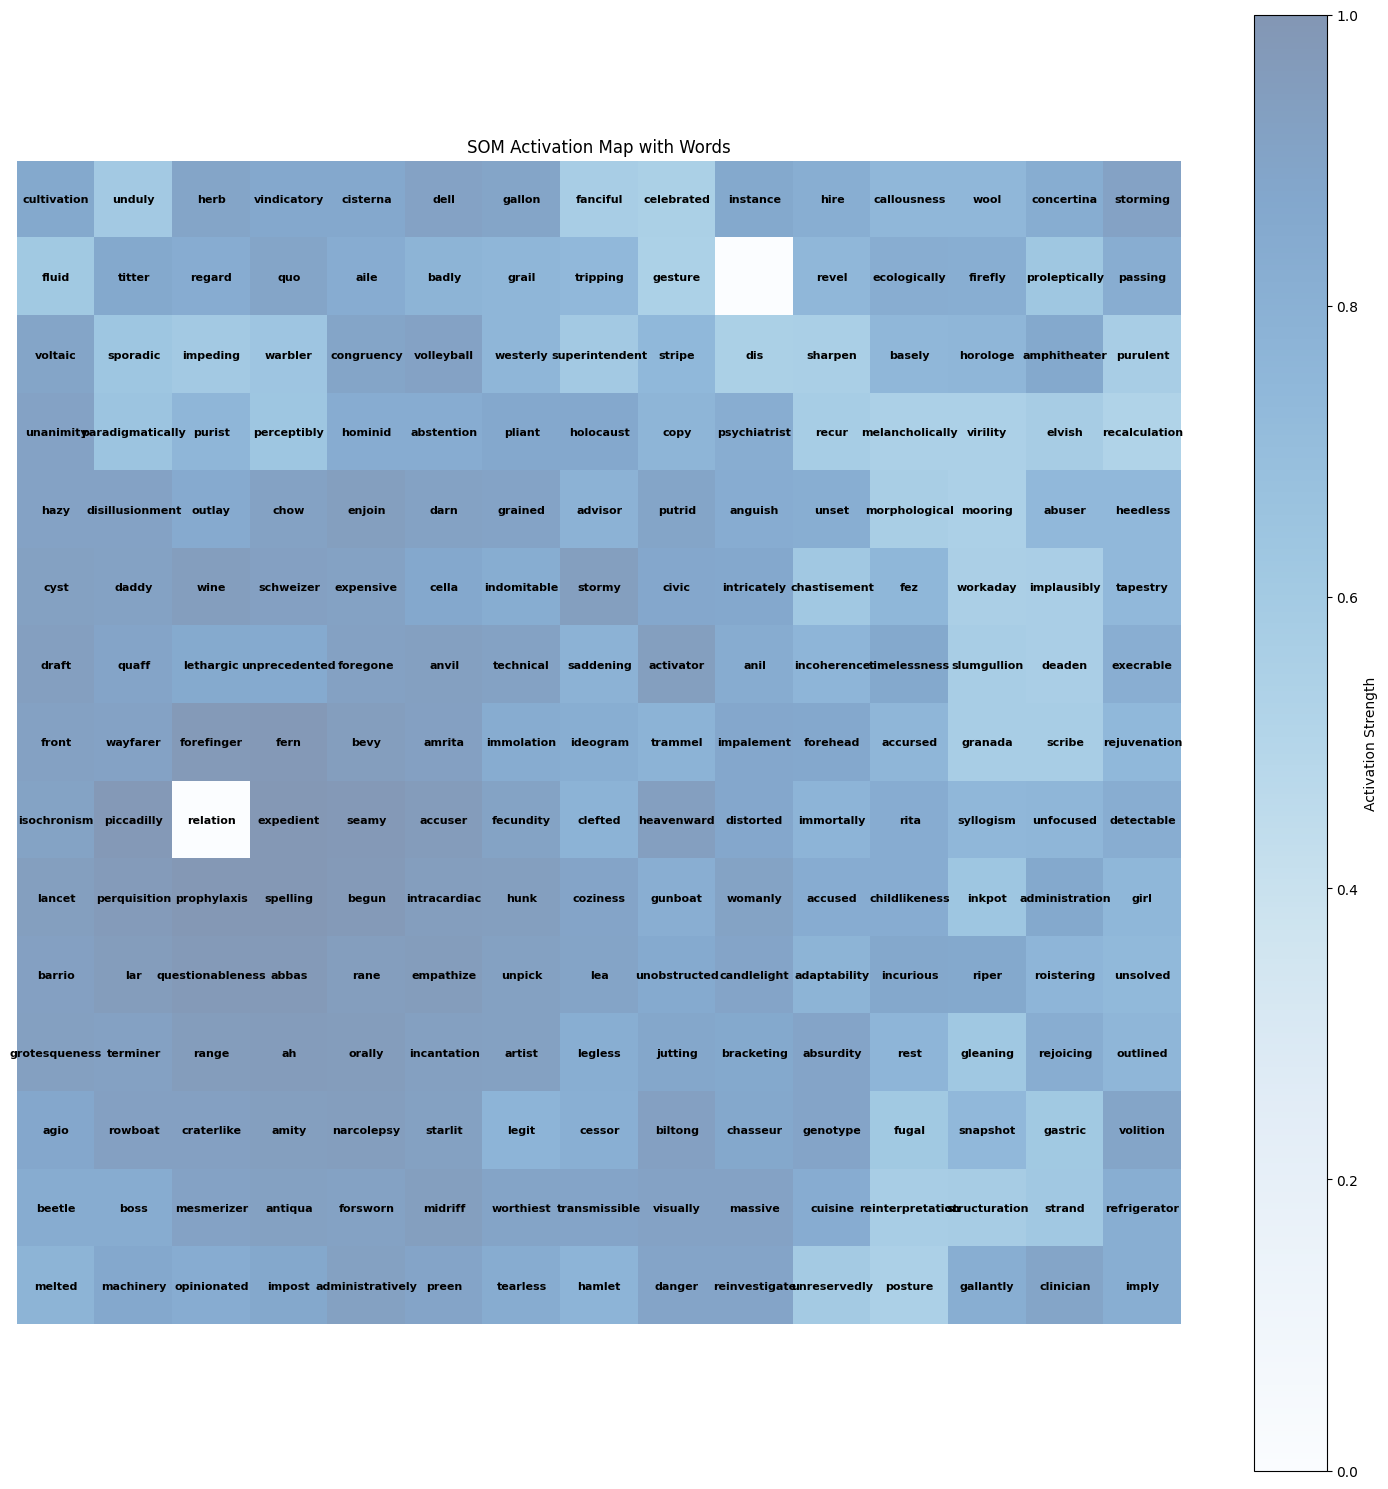

In [48]:
visualize_SOM_uniquewords(SOM, all_processed_words, X_dense, 15, 15)